# No combined closed_as values

In [1]:
#imports
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import chi2_contingency

In [2]:
#load the files after they are clean
eugene = pd.read_csv("full_eugene.csv")
springfield = pd.read_csv("full_springfield.csv")

In [3]:
eugene["city"] = "Eugene"
eugene["calltime"] = pd.to_datetime(eugene["calltime"], errors="coerce")

In [4]:
#Times
mcslc_start = min(eugene[eugene["agency"] == "MCSLC"]["calltime"])
cahoots_end =  max(eugene[eugene["is_cahoots"] == True]["calltime"])
first_time = min(eugene["calltime"])
last_time = max(eugene["calltime"])
print(first_time, mcslc_start, cahoots_end, last_time)

2015-01-01 00:00:00 2024-08-18 00:00:00 2025-04-07 04:33:08 2025-12-31 23:56:03


In [5]:
springfield.rename(columns={"prime unit":"primeunit"}, inplace=True)
springfield["city"] = "Springfield"
springfield["calltime"] = pd.to_datetime(springfield["calltime"], errors="coerce")
if "Call Year" in springfield.columns:
    springfield = springfield.drop(["Call Year"], axis=1) #"ID", "City", "Dispatch Date & Time"
springfield.head(5)

,agency,primeunit,closed_as,calltime,yr,month,is_cahoots,city
0,SPD,1S12,ASSISTED,2015-01-01 00:01:00,2015.0,1.0,False,Springfield
1,SPD,,DISREGARD,2015-01-01 00:04:00,2015.0,1.0,False,Springfield
2,SPD,3S12,ARREST,2015-01-01 00:11:00,2015.0,1.0,False,Springfield
3,SPD,1S12,TRAFFIC STOP ONLY,2015-01-01 00:14:00,2015.0,1.0,False,Springfield
4,SPD,1S18,TRAFFIC STOP ONLY,2015-01-01 00:17:00,2015.0,1.0,False,Springfield


In [6]:
#concatonating the dataframes into one
eug_sp = pd.concat([eugene, springfield], ignore_index=True)

#standardizing some close codes
eug_sp.replace({'SOBERING OR DETOX FACILITY':'SOBERING/DETOX FACILITY',
                 'REFUSED SERVICE - CAHOOTS':'REFUSED SERVICES (CAHOOTS)',
                 'BUILDING CHECK SECURE': 'BUILDING CHECKED SECURE',
                 'REFUSED SERVICES': 'REFUSED SERVICE',
                 'FIRE - NO DAMAGE':'FIRE NO DAMAGE'}, inplace=True)
eug_sp["date"] = eug_sp["calltime"].dt.strftime('%m/%Y')
eug_sp.head(5)

,calltime,closed_as,agency,primeunit,is_cahoots,yr,month,city,date
0,2015-01-01 00:00:00,ASSISTED,EPD,_5E48,False,2015.0,1.0,Eugene,01/2015
1,2015-01-01 00:00:44,RESOLVED,EPD,_3F65,False,2015.0,1.0,Eugene,01/2015
2,2015-01-01 00:01:05,ASSISTED,CAHE,_3J79,True,2015.0,1.0,Eugene,01/2015
3,2015-01-01 00:03:16,PATROL CHECK,EPD,_5E48,False,2015.0,1.0,Eugene,01/2015
4,2015-01-01 00:03:34,ADVISED,EPD,_5K97,False,2015.0,1.0,Eugene,01/2015


In [7]:
#top 5 per agency close codes
split_pd = eug_sp[eug_sp["agency"].isin(["EPD ", "SPD "])]["closed_as"].value_counts().reset_index().iloc[:6]
split_cah = eug_sp[eug_sp["agency"] == "CAHE"]["closed_as"].value_counts().reset_index().iloc[:6]
split_mcs = eug_sp[eug_sp["agency"] == "MCSLC"]["closed_as"].value_counts().reset_index().iloc[:6]

split_codes = pd.concat([split_pd["closed_as"], split_cah["closed_as"], split_mcs["closed_as"]]).unique()
print(split_codes)


['REPORT TAKEN' 'ADVISED' 'PATROL CHECK' 'INFORMATION ONLY' 'ASSISTED'
 'UNABLE TO LOCATE' 'DISREGARD' 'GONE ON ARRIVAL' 'TRANSPORT MADE'
 'RESOLVED' 'REMAINED IN COMMUNITY' 'EMERGENCY DEPARTMENT' 'OTHER'
 'SOBERING/DETOX FACILITY' 'ARREST' 'RESPITE']


In [8]:
eug_sp_reduced = eug_sp[eug_sp["closed_as"].isin(split_codes)]
eug_sp_reduced.head(5)

,calltime,closed_as,agency,primeunit,is_cahoots,yr,month,city,date
0,2015-01-01 00:00:00,ASSISTED,EPD,_5E48,False,2015.0,1.0,Eugene,01/2015
1,2015-01-01 00:00:44,RESOLVED,EPD,_3F65,False,2015.0,1.0,Eugene,01/2015
2,2015-01-01 00:01:05,ASSISTED,CAHE,_3J79,True,2015.0,1.0,Eugene,01/2015
3,2015-01-01 00:03:16,PATROL CHECK,EPD,_5E48,False,2015.0,1.0,Eugene,01/2015
4,2015-01-01 00:03:34,ADVISED,EPD,_5K97,False,2015.0,1.0,Eugene,01/2015


## Analysis ##

In [9]:
def freq_graphs(df, mcslc_start, cahoots_end):
        #plot
        df["date"] = pd.to_datetime(df["date"])
        p = sns.relplot(data=df, 
                x="date", 
                y="count", 
                hue="city", 
                col="closed_as", 
                kind="line",
                facet_kws={"sharey": False})
        p.set_axis_labels("Year", "Count of Calls")
        p.set_titles("{col_name}")
        #plotting vertical lines for mcslc start and cahoots end
        for ax in p.axes.flat:
                ax.axvline(mcslc_start, color="green", linestyle="--", linewidth=1)
                ax.axvline(cahoots_end, color="orange", linestyle="--", linewidth=1)

                ymax = ax.get_ylim()[1]

                ax.text(mcslc_start, ymax, "MCSLC start",
                        rotation=90, va="bottom", ha="right")

                ax.text(cahoots_end, ymax, "CAHOOTS end",
                        rotation=90, va="bottom", ha="right")
        return 


C:\Users\brook\AppData\Local\Temp\ipykernel_15088\2211656492.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])


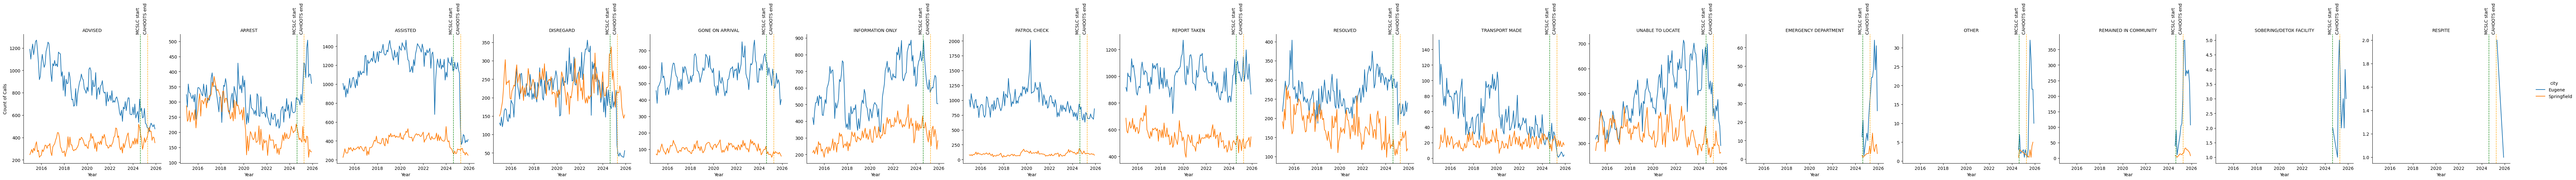

In [10]:
five_agency_counts = (eug_sp_reduced.groupby(["date", "closed_as", "city"]).size().reset_index(name="count"))

mcslc_start = min(eugene[eugene["agency"] == "MCSLC"]["calltime"])
cahoots_end =  max(eugene[eugene["is_cahoots"] == True]["calltime"])
#mcslc_start_year = mcslc_start.year
#cahoots_end_year = cahoots_end.year

freq_graphs(five_agency_counts, mcslc_start, cahoots_end)
#five_agency_counts.head(3)

In [11]:
five_agency_counts["closed_as"].unique()

array(['ADVISED', 'ARREST', 'ASSISTED', 'DISREGARD', 'GONE ON ARRIVAL',
       'INFORMATION ONLY', 'PATROL CHECK', 'REPORT TAKEN', 'RESOLVED',
       'TRANSPORT MADE', 'UNABLE TO LOCATE', 'EMERGENCY DEPARTMENT',
       'OTHER', 'REMAINED IN COMMUNITY', 'SOBERING/DETOX FACILITY',
       'RESPITE'], dtype=object)

From the above graphs I asked myself are any of these informative or interesting? Note that eugene is blue and springfield is orange, also that the above graphs are not the whole set just the smaller one but I did run the whole set and that's how I determined some of the results. I found that some close codes were informative and some weren't...
- Potentially : "DISREGARDED", "TRANSPORT MADE", "UNABLE TO LOCATE"
- Were: "ACCIDENTILY CHOSE NEW EVENT", "ADVISED", "ARREST", "ASSISTED", "REPORT TAKEN", "RESOLVED", "CIVIL ISSUE", "DISREGARDED BY DISPATCH", "NON CRIMINAL HOLD", "RESOLVED", "QUIET ON ARRIVAL"

C:\Users\brook\AppData\Local\Temp\ipykernel_15088\2211656492.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])


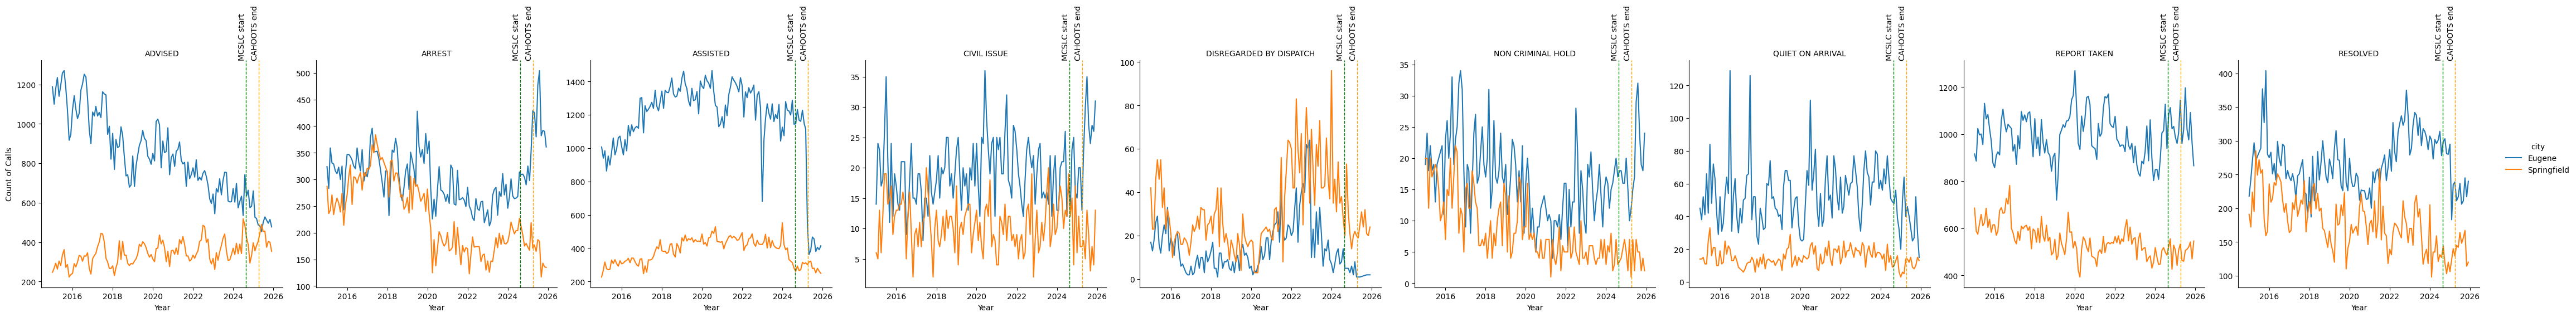

In [12]:
interesting_close_codes = ["ACCIDENTILY CHOSE NEW EVENT", "ADVISED", "ARREST", "ASSISTED", "REPORT TAKEN", "RESOLVED", "CIVIL ISSUE", "DISREGARDED BY DISPATCH", "NON CRIMINAL HOLD", "RESOLVED", "QUIET ON ARRIVAL"]
df_interesting = eug_sp[eug_sp["closed_as"].isin(interesting_close_codes)].copy()
df_interesting_counts = (df_interesting.groupby(["date", "closed_as", "city"]).size().reset_index(name="count"))

freq_graphs(df_interesting_counts, mcslc_start, cahoots_end)

C:\Users\brook\AppData\Local\Temp\ipykernel_15088\2211656492.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])


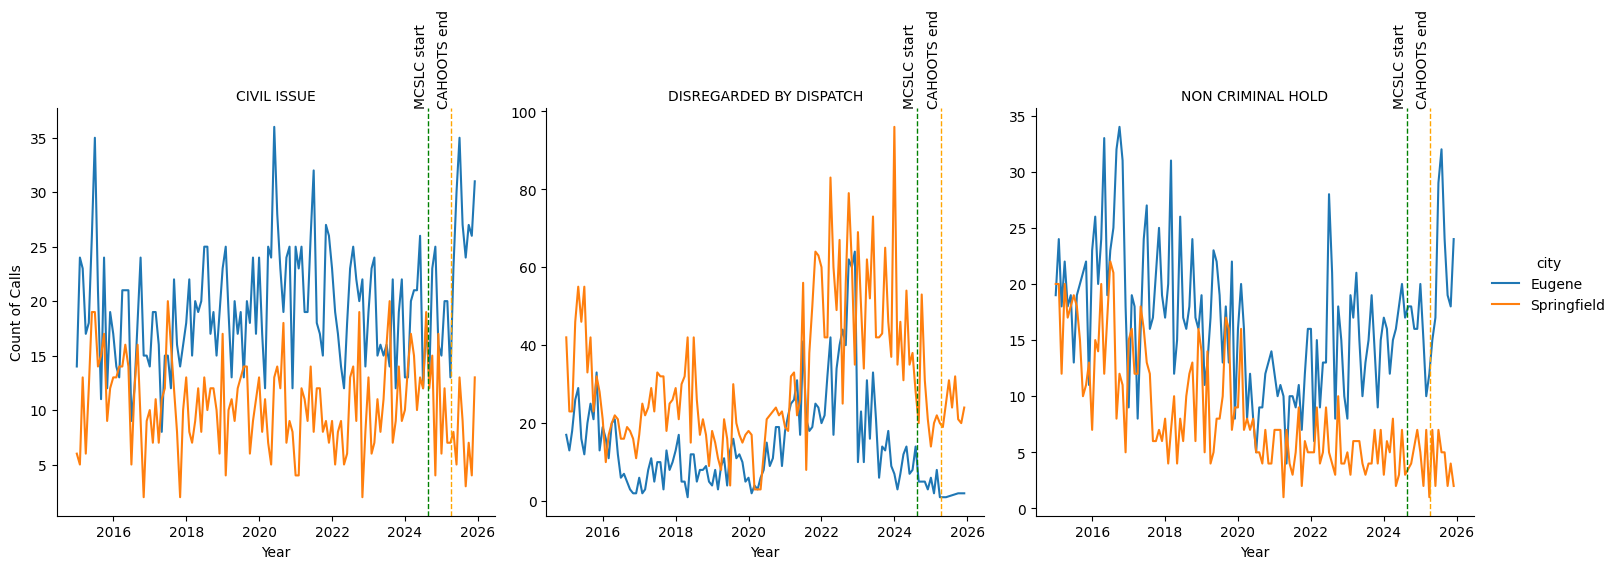

In [14]:
#did = ["ADVISED", "ARREST", "ASSISTED"]
did = ["CIVIL ISSUE", "DISREGARDED BY DISPATCH", "NON CRIMINAL HOLD"]
df_interesting_counts_reduced =  eug_sp[eug_sp["closed_as"].isin(did)].copy()
df_interesting_counts_reduced = (df_interesting_counts_reduced.groupby(["date", "closed_as", "city"]).size().reset_index(name="count"))
freq_graphs(df_interesting_counts_reduced, mcslc_start, cahoots_end)

In [15]:
#Total counts by agency and closed_as hospital or arrest
c = (df_interesting.groupby(["agency", "closed_as", "city"]).size().reset_index(name="count"))
print(c["count"].min())
c.head(25)

1


,agency,closed_as,city,count
0,CAHE,ADVISED,Eugene,1550
1,CAHE,ADVISED,Springfield,906
2,CAHE,ARREST,Eugene,3
3,CAHE,ARREST,Springfield,3
4,CAHE,ASSISTED,Eugene,90202
5,CAHE,ASSISTED,Springfield,29500
6,CAHE,CIVIL ISSUE,Springfield,1
7,CAHE,DISREGARDED BY DISPATCH,Eugene,1736
8,CAHE,DISREGARDED BY DISPATCH,Springfield,9
9,CAHE,NON CRIMINAL HOLD,Eugene,1


## Multinomial Logistic Regression ##

- Goal: to see if call type can be predicted with agency?

In [16]:
#using the dataframe df_interesting, defined above, beacuse it is already filtered for the interesting close codes. 

#Train test split
#Use agency and city as predictors and include month and year to control for variations. 
X = pd.get_dummies(
    df_interesting[["agency", "city", "yr", "month"]],
    drop_first=True
)
y = df_interesting["closed_as"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#logistic regression model
model = LogisticRegression(max_iter=5000, class_weight="balanced")
model.fit(X_train, y_train)

#make predictions and evaluate accuracy and results
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, preds))
print("classification report:", classification_report(y_test, preds))

KeyboardInterrupt: 

### results ###

classification report:                          
precision    recall  	f1-score   	support
                ADVISED       0.28     	 0.69      	0.40     	30980
                 ARREST       0.00      	0.00      	0.00    	 14185
               ASSISTED       0.91      	0.58      	0.71     	41338
            CIVIL ISSUE       0.00      	0.00     	 0.00       	788
        DISREGARDED BY
               DISPATCH       0.02      0.67      0.04      1224
      NON CRIMINAL
 HOLD           0.00      0.00      	0.00       	652
QUIET ON ARRIVAL       0.00      0.00      0.00      1752
     REPORT TAKEN       0.00      0.00      0.00     40534
            RESOLVED       0.00      0.00      0.00     11765

               accuracy                           0.32    143218
              macro avg       0.13      0.22      0.13    143218
           weighted avg       0.32      0.32      0.29    143218


# Chi-Squared Test

In [17]:
table = pd.crosstab(
    #df_interesting
    eug_sp["agency"],
    eug_sp["closed_as"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 2698133.5362083623
P-value: 0.0


In [18]:
observed = table.values

residuals = (observed - expected) / np.sqrt(expected)

residuals = pd.DataFrame(
    residuals,
    index=table.index,
    columns=table.columns
)

#print(residuals.round(2))

### Top residuals for the whole dataset eug_sp. ##
residuals_long = (
    residuals
    .stack()
    .reset_index()
)

residuals_long.columns = [
    "agency",
    "close_code",
    "residual"
]

# absolute value
residuals_long["abs_resid"] = (
    residuals_long["residual"].abs()
)

# keep strongest signals
top = (
    residuals_long
    .sort_values("abs_resid", ascending=False)
    .head(20)
)

print(top.round(2))

    agency                close_code  residual  abs_resid
269  MCSLC     REMAINED IN COMMUNITY   1151.27    1151.27
7     CAHE                  ASSISTED    566.99     566.99
223  MCSLC      EMERGENCY DEPARTMENT    488.03     488.03
383   SPD          TRAFFIC STOP ONLY    328.62     328.62
248  MCSLC                     OTHER    267.95     267.95
185   EPD          TRAFFIC STOP ONLY   -199.80     199.80
152   EPD               PATROL CHECK    178.16     178.16
304   SPD                   ASSISTED   -171.69     171.69
87    CAHE            TRANSPORT MADE    170.94     170.94
72    CAHE              REPORT TAKEN   -162.74     162.74
89    CAHE          UNABLE TO LOCATE    151.16     151.16
350   SPD               PATROL CHECK   -149.43     149.43
21    CAHE                 DISREGARD    148.85     148.85
106   EPD                   ASSISTED   -145.04     145.04
53    CAHE              PATROL CHECK   -131.86     131.86
120   EPD                  DISREGARD   -131.16     131.16
4     CAHE    

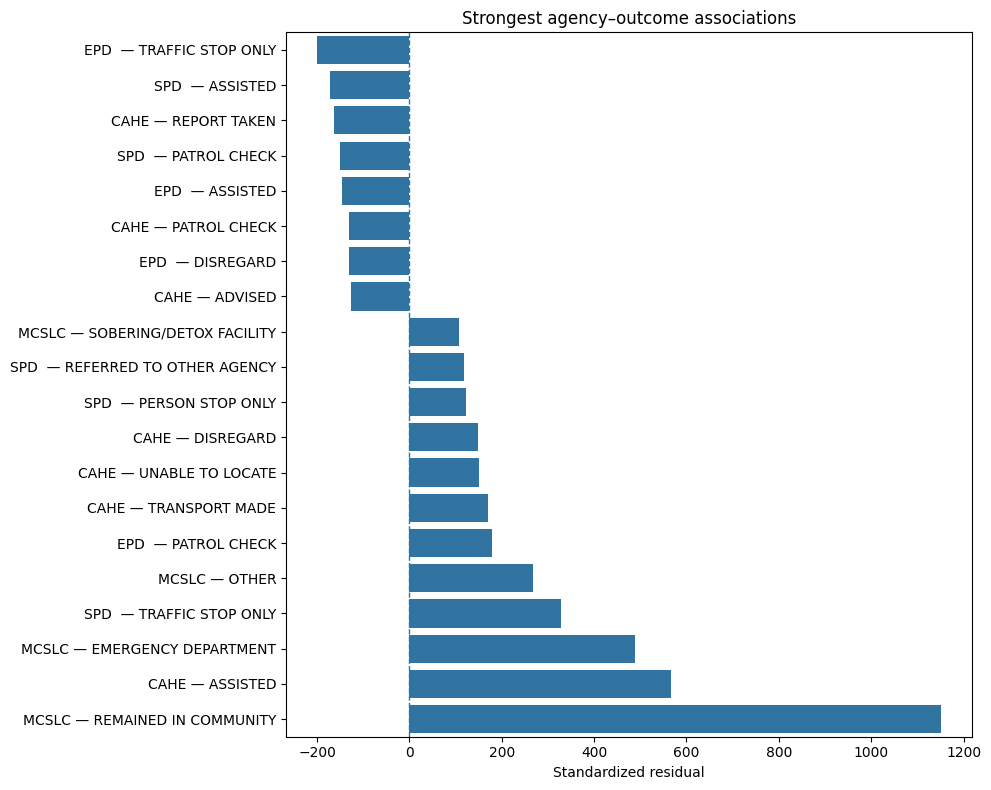

In [22]:
#Bar plot to demonstrate agency coorrelation to call close code

# Create readable labels
top["label"] = (
    top["agency"] + " — " + top["close_code"]
)

# Sort so largest bars appear at top
top_sorted = top.sort_values(
    "residual",
    ascending=True
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_sorted,
    x="residual",
    y="label"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Standardized residual")
plt.ylabel("")
plt.title(
    "Strongest agency–outcome associations"
)

plt.tight_layout()
plt.show()

In [19]:
r = pd.DataFrame(residuals)
i = ["REMAINED IN COMMUNITY", "ASSISTED", "EMERGENCY DEPARTMENT", "TRANSPORT MADE", "REPORT TAKEN", "ADVISED", "REFERRED TO OTHER AGENCY", "SOBERING/DETOX FACILITY"]
r[i]


closed_as,REMAINED IN COMMUNITY,ASSISTED,EMERGENCY DEPARTMENT,TRANSPORT MADE,REPORT TAKEN,ADVISED,REFERRED TO OTHER AGENCY,SOBERING/DETOX FACILITY
agency,,,,,,,,
CAHE,-20.087933,566.990450,-8.515367,170.942609,-162.736793,-125.711920,-18.912789,-1.879881
EPD,-41.258957,-145.038342,-17.489861,-65.840688,55.588967,76.640742,-80.088584,-3.861121
MCSLC,1151.267124,-21.785374,488.027419,-4.773838,-21.708559,-19.005722,-5.580605,107.738574
SPD,-31.145390,-171.689320,-13.202674,-22.623288,33.183148,-18.816479,118.771993,-2.914667


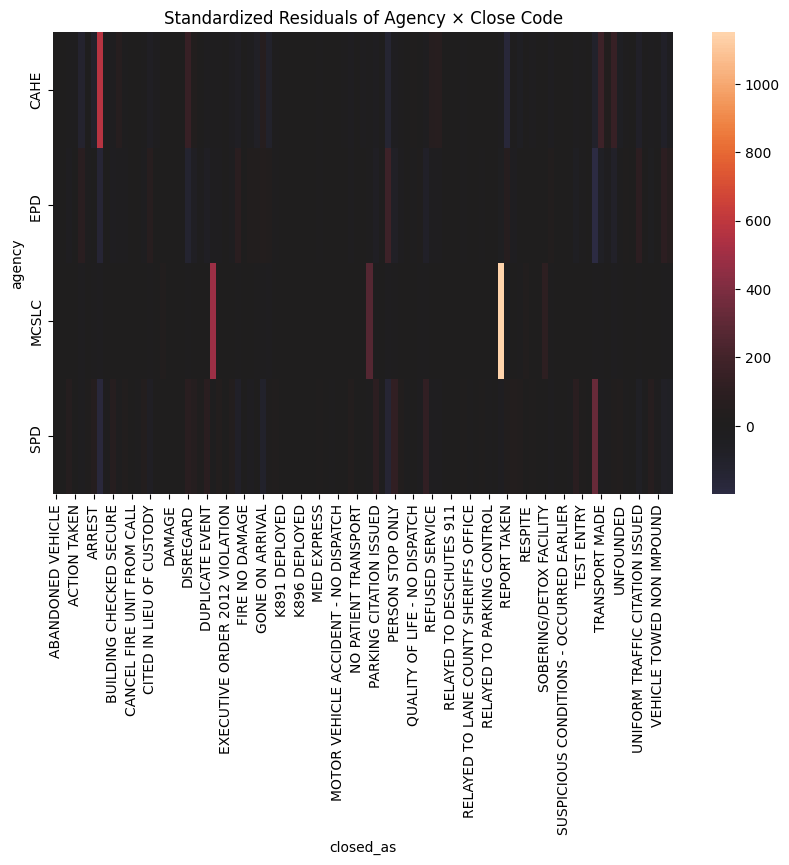

In [20]:
plt.figure(figsize=(10,6))

sns.heatmap(
    residuals,
    annot=False, #true if want numbers in the graph
    center=0,
)

plt.title("Standardized Residuals of Agency × Close Code")
plt.show()

# Difference in Differences

In [ ]:
def city_rate(df, city, close_code):
    """Compute the call rate per city of close code"""
    city_df = df[df["city"] == city] #filter df  by city
    numer = (city_df["closed_as"] == close_code).sum() #filter by close code
    denom = len(city_df) #total length
    return numer / denom

def dind (df, time, close_code):
    """This function does difference in differences analysis
    on a chosen dataframe (df) that have columns "city" and "calltime" at least."""
    pre = df[df["calltime"] < time]
    post = df[df["calltime"] >= time]

    treated_post = city_rate(post, "Eugene", close_code)
    treated_pre = city_rate(pre, "Eugene", close_code)
    control_post = city_rate(post, "Springfield", close_code)
    control_pre = city_rate(pre, "Springfield", close_code)
    
    did = (treated_post - treated_pre) - (control_post - control_pre)
    return did

for close_code in interesting_close_codes:
    did = dind(eug_sp, cahoots_end, close_code)
    print(f"The difference for {close_code} is {(round(did*100, 3))}%")


The difference for ACCIDENTILY CHOSE NEW EVENT is 0.0%
The difference for ADVISED is -6.594%
The difference for ARREST is 1.905%
The difference for ASSISTED is -3.588%
The difference for REPORT TAKEN is 0.473%
The difference for RESOLVED is 0.511%
The difference for CIVIL ISSUE is 0.063%
The difference for DISREGARDED BY DISPATCH is -0.088%
The difference for NON CRIMINAL HOLD is 0.143%
The difference for RESOLVED is 0.511%
The difference for QUIET ON ARRIVAL is -0.084%
